# Canada Food CPI — CFPR Replica Experiment

This notebook is a **methodology demonstration**: it shows what an agentic
forecasting pipeline looks like in practice, compares it to conventional
baselines on historical data, and — crucially — explains what those comparisons
can and cannot tell us.

**The leakage problem.** Frontier LLMs like Gemini were trained on data through
late 2024.  For most backtest origins here (2009–2024), the model has likely
been exposed to the resolved outcomes.  A strong CRPS score therefore tells us
the pipeline is working and the model can produce calibrated structured output
— it does not tell us the agent can genuinely forecast the future.  The right
interpretation is an **upper bound**: if a model with perfect recall of
historical outcomes scores X, a live deployment should aspire to approach X on
unresolved tasks.

Set `EXPERIMENT_CONFIG` in the config cell to choose the scope:
`mini_single` (1 target, 6 origins — default), `mini_recent` (9 targets, 6 origins),
or `full` (9 targets, 16 origins — canonical CFPR backtest).

**What's here:**

1. Data overview — nine food CPI sub-indices at a glance.
2. Spec + predictors — loaded from YAML; backtest results cached on disk.
3. Qualitative check — trajectory fans and avg/avg YoY grid.
4. Model selection — CRPS and MAPE per category.
5. What next — why live forecasting is the only clean evaluation.


---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py`      registers the 9 StatCan series on a `DataService`.
- `analysis.py`  flattens results to DataFrames and computes avg/avg YoY.
- `plots.py`     renders the figures the CFPR audience expects.

Backtest specs (all under `specs/`):

| Spec file | Tasks | Origins | Notes |
|---|---|---|---|
| `food_cpi_single_mini_backtest.yaml` | 1 (food overall) | 6 (2019–2024) | Fast dev/smoke-test |
| `food_cpi_recent_backtest.yaml` | 9 | 6 (2019–2024) | Recent regimes only |
| `food_cpi_cfpr_backtest.yaml` | 9 | 16 (2009–2024) | Canonical CFPR backtest |

There is no protected eval spec for this experiment — historical LLM and agent
scores are upper bounds on live performance (see the intro).

Run the data fetch once if you haven't:

```bash
uv run python scripts/fetch_cpi.py
```


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env")

import importlib

# Helper to live-reload the plots module during development
import food_price_forecasting
import food_price_forecasting.plots
from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    cached_multi_backtest,
    describe_spec,
)
from aieng.forecasting.methods import DartsAutoARIMAPredictor, LastValuePredictor
from food_price_forecasting.analysis import compute_ape_long, compute_avgyoy, compute_mape, summarize_crps
from food_price_forecasting.data import CATEGORY_LABELS, build_food_cpi_service


importlib.reload(food_price_forecasting.plots)
from food_price_forecasting.plots import (
    plot_avgyoy_grid,
    plot_food_cpi_small_multiples,
    plot_mape_by_category,
    plot_trajectory_fan,
)


STATCAN_CACHE = ROOT / "data" / "statcan"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
SPECS_DIR = ROOT / "implementations" / "food_price_forecasting" / "specs"

svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
print(f"Registered {len(CATEGORY_LABELS)} food CPI series.")

Registered 9 food CPI series.


In [2]:
# ── Experiment configuration ──────────────────────────────────────────────────
# Set EXPERIMENT_CONFIG to control which CFPR backtest runs throughout this
# notebook. All downstream cells adapt automatically.
#
#   "mini_single"  1 target (food overall) × 6 recent origins (Jul 2019–2024)
#                  ~6 agent calls — fastest; ideal for development / smoke test
#   "mini_recent"  9 targets × 6 recent origins (Jul 2019–2024)
#                  ~54 agent calls — covers COVID/inflation regimes
#   "full"         9 targets × 16 origins (Jul 2009–2024)
#                  ~144 agent calls — canonical CFPR backtest

EXPERIMENT_CONFIG = "mini_single"

_BACKTEST_SPEC_FILES = {
    "mini_single": "food_cpi_single_mini_backtest.yaml",
    "mini_recent": "food_cpi_recent_backtest.yaml",
    "full": "food_cpi_cfpr_backtest.yaml",
}
_BACKTEST_SPEC_FILE = _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]

print(f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILE}")

Config: 'mini_single'  →  food_cpi_single_mini_backtest.yaml


---
## 2. Data exploration

A single figure is plenty — the nine sub-indices track each other closely with
a clear post-2020 acceleration.

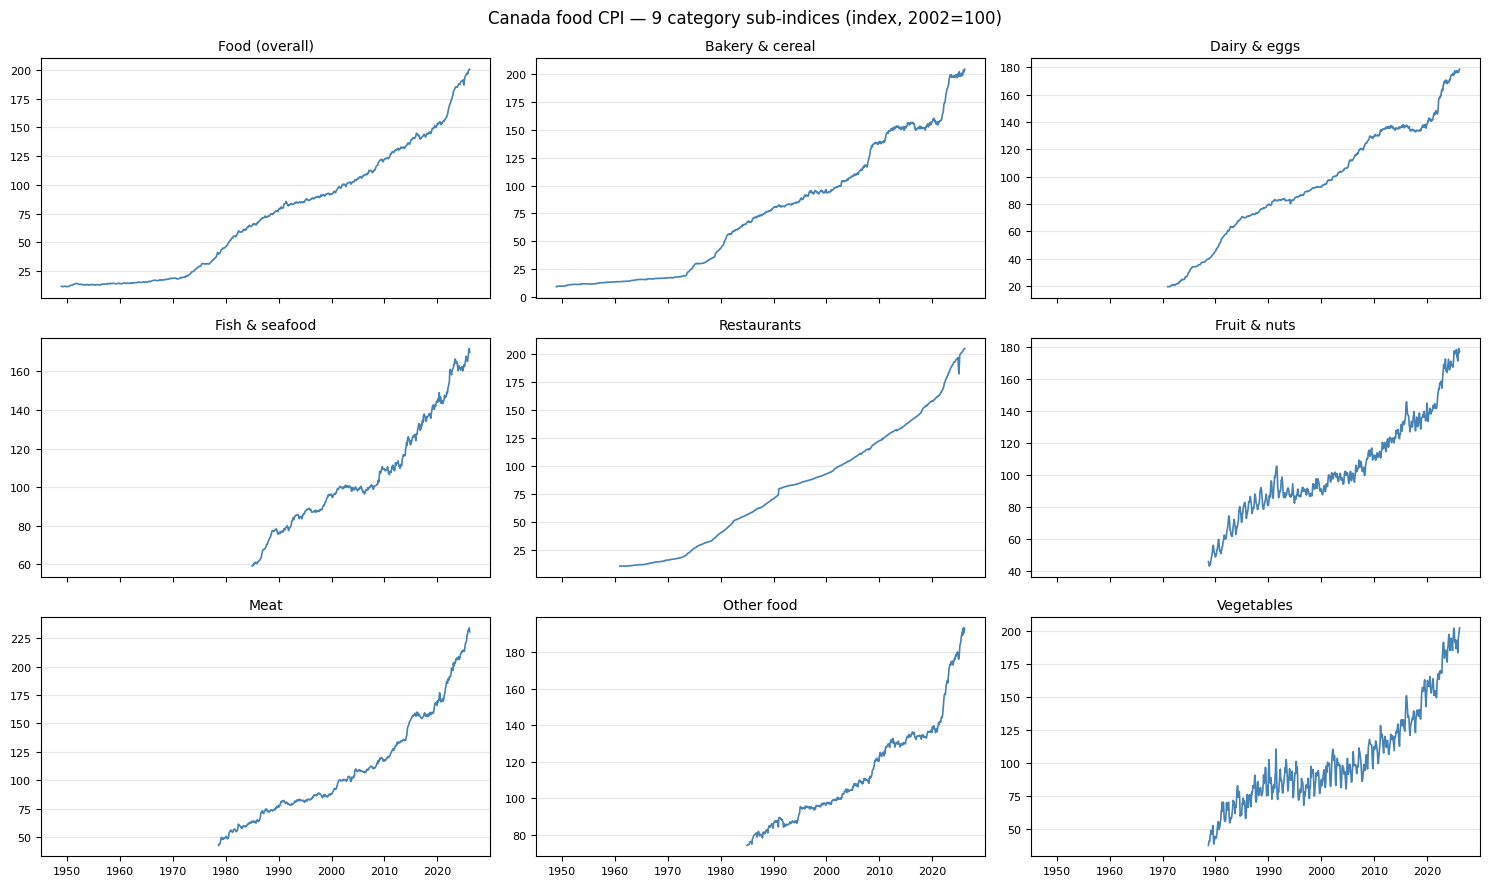

In [3]:
fig, _ = plot_food_cpi_small_multiples(svc)
plt.show()

---
## 3. The backtest spec

The backtest spec is loaded from YAML so the spec (not the notebook) is the
source of truth.  `describe_spec()` renders a plain-text summary suitable for
print, prompts, or documentation.

> **Training window note.** The `full` spec covers origins from July 2009 to
> July 2024.  Gemini's training data extends through late 2024, so virtually
> every origin in this spec — including the most recent ones — falls within the
> model's training window.  The model has plausibly been exposed to resolved
> inflation outcomes for all of these periods.  Keep this in mind when
> interpreting any LLM or agent scores below.

In [4]:
with (SPECS_DIR / _BACKTEST_SPEC_FILE).open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(describe_spec(backtest_spec, data_service=svc))
print(
    f"\nTasks: {len(backtest_spec.tasks)}  Window: {backtest_spec.start.date()} → {backtest_spec.end.date()}  Stride: {backtest_spec.stride}"
)

MultiTargetBacktestSpec (spec_id=food_cpi_single_mini_backtest)
  description: Single-target mini backtest: bakery & cereal CPI, 6 recent annual July origins (2019-2024), 12-step trajectory (horizons 6-17). Use for fast agent development and pipeline smoke-testing. Not budget-gated — run freely.
  start:       2019-07-01 00:00:00
  end:         2024-07-01 00:00:00
  stride:      12
  warmup:      24
  tasks:       1

Task: food_cpi_bakery_cereal_cfpr
  description: Canada CPI Bakery and cereal products (excl. baby food), trajectory across Jan-Dec of the year following a July origin.
  horizons:    [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] (len=12)
  frequency:   MS
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: cpi_bakery_cereal_canada
    description:    CPI Bakery and cereal products (excl. baby food), Canada (2002=100)
    source:         Statistics Canada
    units:          Index 2002=100
    frequency:      MS


Tasks: 1  Window: 2019-07-01 → 2024-07

---
## 4. Predictors

Four predictors across two groups, each implementing the same `Predictor`
API against the configured backtest spec. Swap in your own subclass or add
to `all_predictors` to run it through the full evaluation loop.

| Group | Predictor | Notes |
|---|---|---|
| Baselines | `LastValuePredictor` | Repeats last observed value; hard to beat at short horizons. |
| Baselines | `DartsAutoARIMAPredictor` | Auto-ARIMA via Darts; fits at each origin. |
| LLMP ×2 | `ContinuousLLMPredictor` | Direct LLM call; structured JSON trajectory; no tools or search. |

### LLM Processes (LLMPs)

`ContinuousLLMPredictor` represents a direct, direct-prompting LLM forecasting approach (an LLM Process or LLMP). At each origin, it receives the target series history as text and generates the full 12-month trajectory directly as a structured JSON object.

### Leakage on Historical Backtests

Even with direct prompting (no search tools enabled), a frontier LLM is not a blank slate. The model weights encode a compressed representation of its training corpus — which, for Gemini, includes news, statistics, and economic commentary up to its training cutoff. For a July 2021 origin, the model implicitly "knows" that food inflation spiked in 2022. This is not a bug that can be filtered away; it is structural. The LLMP predictors are therefore not producing genuine out-of-sample forecasts for these historical origins — they are producing calibrated reconstructions of an outcome the model has already, in some sense, seen.

This is why a side-by-side comparison with ARIMA on a historical backtest is not a fair contest. ARIMA has no access to future information; the LLM does. The right framing is: **the LLMP backtest score is an approximate upper bound** on what you might expect from a live deployment on unresolved tasks.

In [5]:
import pandas as pd
from aieng.forecasting.methods import ContinuousLLMPredictor, ContinuousLLMPredictorConfig


# ── Baselines ─────────────────────────────────────────────────────────────────
lv = LastValuePredictor()
arima = DartsAutoARIMAPredictor()

# ── LLM predictors (direct structured output, no tools) ───────────────────────
llmp_flash3 = ContinuousLLMPredictor(ContinuousLLMPredictorConfig(model="gemini/gemini-3-flash-preview", n_samples=3))
llmp_flash3_5 = ContinuousLLMPredictor(ContinuousLLMPredictorConfig(model="gemini/gemini-3.5-flash", n_samples=3))

all_predictors = [
    lv,
    arima,
    llmp_flash3,
    llmp_flash3_5,
]

# Colors: gray/blue = baselines, red = LLMP
PREDICTOR_COLORS: dict[str, str] = {
    lv.predictor_id: "#7f7f7f",
    arima.predictor_id: "#1f77b4",
    llmp_flash3.predictor_id: "#d62728",
    llmp_flash3_5.predictor_id: "#e87070",
}

PREDICTOR_LABELS: dict[str, str] = {
    lv.predictor_id: "Naive",
    arima.predictor_id: "AutoARIMA",
    llmp_flash3.predictor_id: "LLMP 3-flash",
    llmp_flash3_5.predictor_id: "LLMP 3.5-flash",
}

for p in all_predictors:
    print(f"  {p.predictor_id}")

09:48:53 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
09:48:54 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


  last_value_naive
  darts_autoarima
  llmp_continuous[gemini/gemini-3-flash-preview]
  llmp_continuous[gemini/gemini-3.5-flash]


---
## 5. Backtest (cached on disk)

`cached_multi_backtest` writes each `BacktestResult` to
`data/predictions/<spec_id>/<predictor_id>/<task_id>.yaml` and reuses it on
subsequent runs.  Pass `force_refresh=True` to re-run a predictor from scratch.

All predictors run against the configured backtest spec (set in the config cell above).
`ContinuousLLMPredictor` and the agent predictor make API calls on a first run
(~6 / ~54 / ~144 calls for `mini_single` / `mini_recent` / `full` respectively);
subsequent runs are free from cache.

**What this backtest is measuring:**

| What we learn | What we don't learn |
|---|---|
| The pipeline runs end-to-end without errors | Whether the agent can forecast genuinely unseen data |
| The model produces valid calibrated structured output | Whether strong scores reflect skill or memorization |
| An approximate upper bound on live performance | How the agent performs when the future is actually unknown |

Think of it this way: a human expert who had already read the outcome would
also beat ARIMA.  The interesting question — whether the agent provides useful
calibrated uncertainty when the future is genuinely open — can only be answered
by forecasting tasks that haven't resolved yet.


In [6]:
results_by_predictor: dict[str, dict[str, object]] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:42s}  mean CRPS = {result.mean_crps:.4f}  ({len(result.predictions)} preds)")

Running last_value_naive ...
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 8.1375  (72 preds)
Running darts_autoarima ...
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 8.8338  (72 preds)
Running llmp_continuous[gemini/gemini-3-flash-preview] ...


09:48:56 - LiteLLM:WARNING: opentelemetry.py:230 - Proxy Server is not installed. Skipping OpenTelemetry initialization.


  food_cpi_bakery_cereal_cfpr                 mean CRPS = 4.3823  (72 preds)
Running llmp_continuous[gemini/gemini-3.5-flash] ...
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 4.5123  (72 preds)


---
## 6. Trajectories — focal series

Show the three most recent origins for the focal series (`FOCAL_TASK`, derived
from the first task in the backtest spec) with each predictor's 12-step
trajectory fan.  Solid black is observed history, dashed black is Y+1 actuals
where available, fans are the predictor's 90%/50% intervals with the median in
colour.

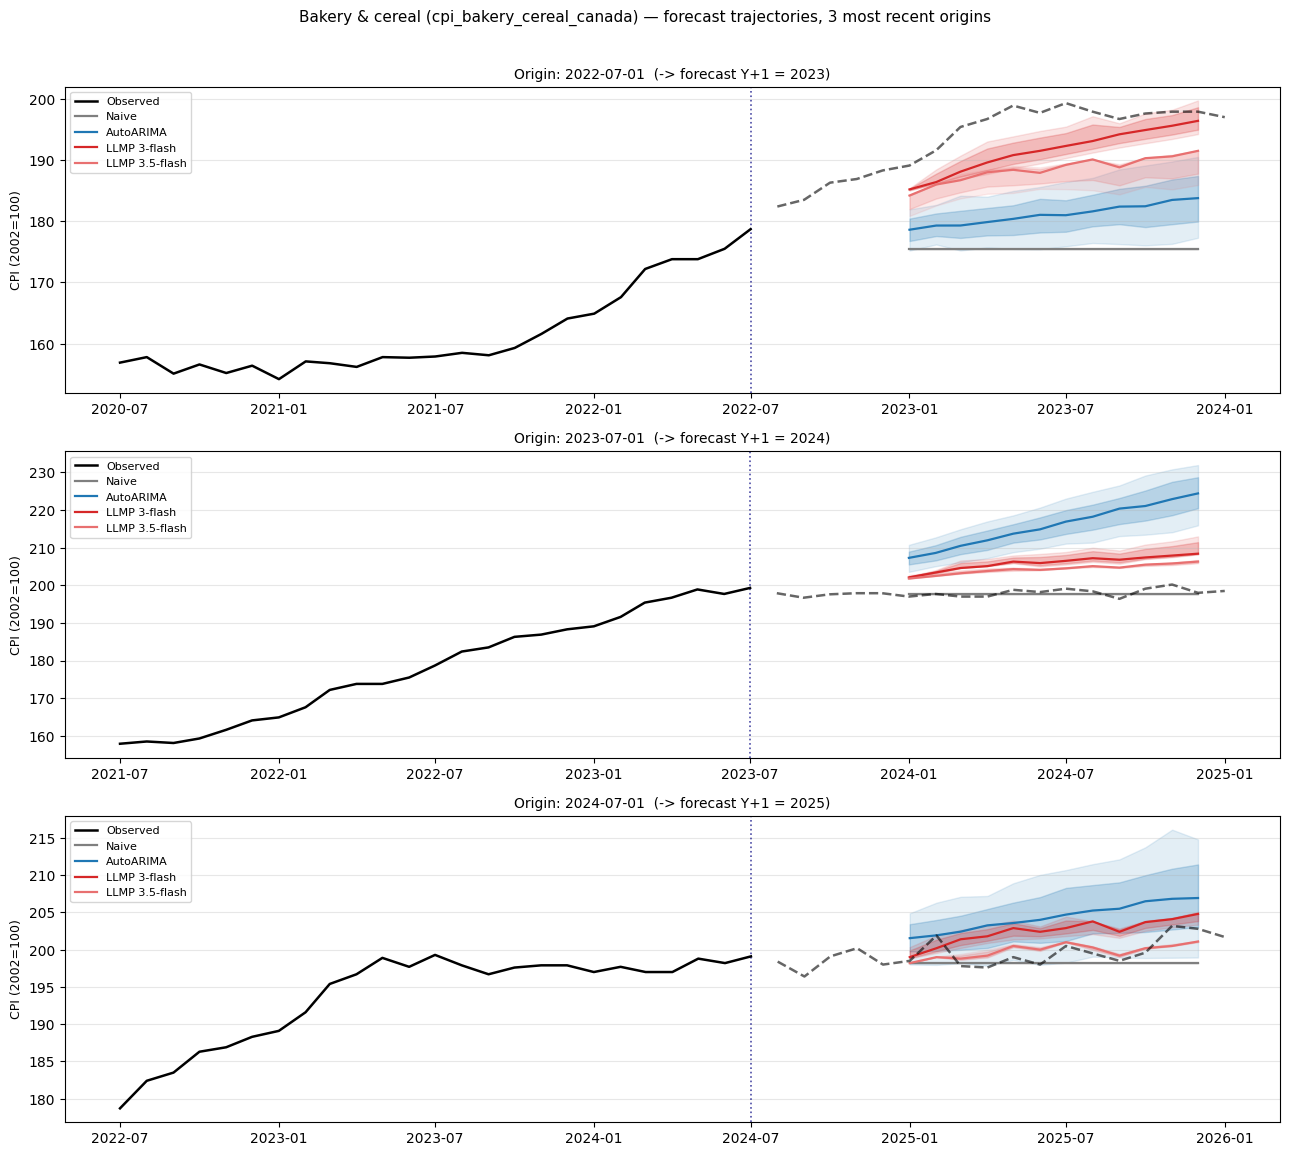

In [7]:
# Derive from the first task in the loaded spec so this adapts to any config.
FOCAL_TASK = backtest_spec.tasks[0].task_id
FOCAL_SERIES = backtest_spec.tasks[0].target_series_id

fig, _ = plot_trajectory_fan(
    results_by_predictor=results_by_predictor,
    task_id=FOCAL_TASK,
    category_id=FOCAL_SERIES,
    data_service=svc,
    n_recent=3,
    colors=PREDICTOR_COLORS,
    labels=PREDICTOR_LABELS,
)
plt.show()

---
## 7. Avg/avg YoY — food CPI categories

The headline CFPR metric: for each July origin, mean predicted CPI for year Y+1
divided by mean observed CPI for year Y, minus 1.  Actual realised YoY (solid
black) is the out-of-sample truth for every completed year.

**Note on the 2022 spike:** LLMP with `reasoning_effort="disable"` anchors its
extrapolation on the *current level* rather than the *rate of change*, so it
tends to underestimate carry-through during a mid-surge origin.  This is a
known limitation of level-domain direct prompting (Gruver / CiK), not a
data-feeding issue.


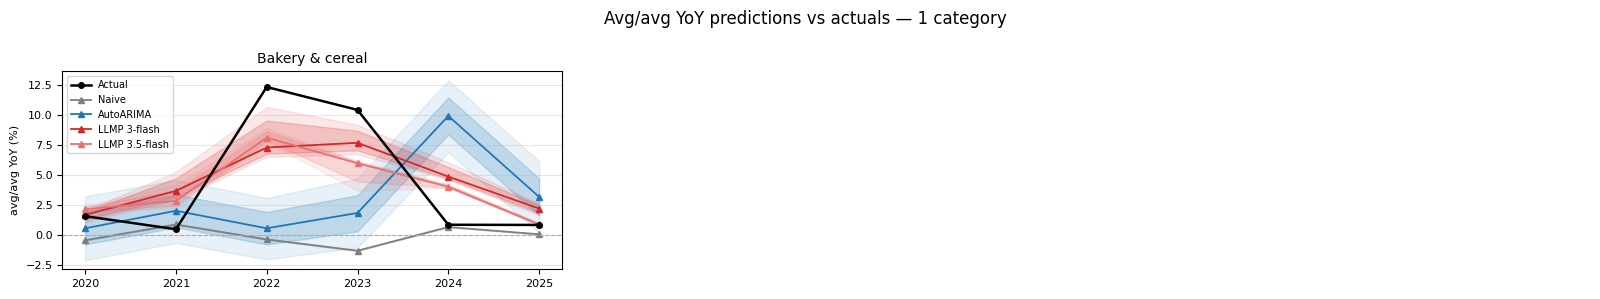

In [8]:
from datetime import datetime, timezone


yoy_by_predictor_by_task: dict[str, dict[str, object]] = {}
task_to_category: dict[str, str] = {task.task_id: task.target_series_id for task in backtest_spec.tasks}

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)

for pid, task_results in results_by_predictor.items():
    yoy_by_predictor_by_task[pid] = {}
    for task_id, result in task_results.items():
        actual_df = svc.get_series(result.spec.task.target_series_id, as_of=_as_of)
        yoy_by_predictor_by_task[pid][task_id] = compute_avgyoy(result, actual_df)

fig, _ = plot_avgyoy_grid(
    yoy_by_predictor_by_task=yoy_by_predictor_by_task,
    task_to_category=task_to_category,
    colors=PREDICTOR_COLORS,
    labels=PREDICTOR_LABELS,
)
plt.show()

---
## 8. Model selection

A note on interpreting scores for LLM-based predictors: because these backtest
origins are within the training window of frontier models, low CRPS values
reflect a combination of (a) genuine calibration quality and (b) the model
"recalling" outcomes it has implicitly seen.  These two contributions cannot be
separated from the backtest alone.  Use the scores to confirm the pipeline is
working and to establish a performance ceiling, not to draw conclusions about
live predictive skill.

### 8.1 CRPS per category

Lower is better.  The `MEAN` row is the across-category average — useful
context, but the per-category rows are the basis for model selection.

In [9]:
crps_board = summarize_crps(results_by_predictor)
print(crps_board.to_string())

predictor_id                 darts_autoarima  last_value_naive  llmp_continuous[gemini/gemini-3-flash-preview]  llmp_continuous[gemini/gemini-3.5-flash]
task_id                                                                                                                                                 
food_cpi_bakery_cereal_cfpr           8.8338            8.1375                                          4.3823                                    4.5123
MEAN                                  8.8338            8.1375                                          4.3823                                    4.5123


### 8.2 MAPE per category

Median-accuracy sanity check (CRPS is the primary selection metric).  One panel
per sub-index; each box spans the distribution of per-prediction absolute
percentage errors across all backtest origins and horizons.

predictor_id                 darts_autoarima  last_value_naive  llmp_continuous[gemini/gemini-3-flash-preview]  llmp_continuous[gemini/gemini-3.5-flash]
task_id                                                                                                                                                 
food_cpi_bakery_cereal_cfpr            5.416             4.392                                           2.831                                     2.528


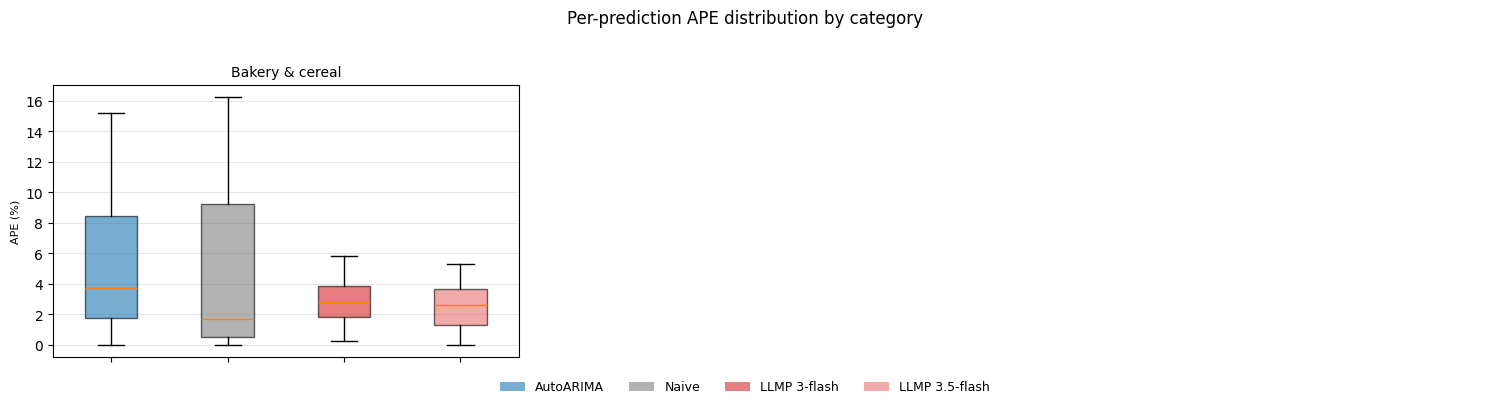

In [10]:
mape_df = compute_mape(results_by_predictor, data_service=svc)
print(mape_df.to_string())

ape_long = compute_ape_long(results_by_predictor, data_service=svc)
fig, _ = plot_mape_by_category(
    ape_long,
    task_to_category=task_to_category,
    colors=PREDICTOR_COLORS,
    labels=PREDICTOR_LABELS,
)
plt.show()

---
## 9. Backtest-average avg/avg YoY — headline table

Model selection is done **per category**: for each food CPI sub-index the
predictor with the lowest mean CRPS over all backtest origins and horizons for
that category is selected independently.  The table below shows each
category's best predictor and its avg/avg YoY central estimate and uncertainty
band averaged across the full backtest window.

In [11]:
# Best predictor per category, selected by that category's own mean CRPS.
best_pid_by_task: dict[str, str] = crps_board.drop(index="MEAN").idxmin(axis=1).to_dict()
print("Best predictor by category (mean CRPS over full backtest window):")
for task_id, pid in best_pid_by_task.items():
    category = CATEGORY_LABELS.get(task_to_category[task_id], task_id)
    print(f"  {category:<40s} {pid}")

rows: list[dict[str, object]] = []
for task_id, pid in best_pid_by_task.items():
    yoy_df = yoy_by_predictor_by_task[pid].get(task_id)
    if yoy_df is None or yoy_df.empty:
        continue
    avg = yoy_df[["yoy_median", "yoy_q05", "yoy_q25", "yoy_q75", "yoy_q95", "actual_yoy"]].mean()
    rows.append(
        {
            "category": CATEGORY_LABELS.get(task_to_category[task_id], task_id),
            "best_predictor": pid,
            "median_yoy_%": round(avg["yoy_median"] * 100, 2),
            "q05_%": round(avg["yoy_q05"] * 100, 2),
            "q25_%": round(avg["yoy_q25"] * 100, 2),
            "q75_%": round(avg["yoy_q75"] * 100, 2),
            "q95_%": round(avg["yoy_q95"] * 100, 2),
            "actual_yoy_%": round(avg["actual_yoy"] * 100, 2),
        }
    )

headline = pd.DataFrame(rows).set_index("category")
print()
print(headline.to_string())

Best predictor by category (mean CRPS over full backtest window):
  Bakery & cereal                          llmp_continuous[gemini/gemini-3-flash-preview]

                                                 best_predictor  median_yoy_%  q05_%  q25_%  q75_%  q95_%  actual_yoy_%
category                                                                                                               
Bakery & cereal  llmp_continuous[gemini/gemini-3-flash-preview]          4.57   3.93   4.15   5.51   5.98          4.42


---
## 10. What next — live forecasting as the only clean evaluation

This notebook demonstrates that the LLMP pipeline works: predictors run,
structured output is validated, results are cached, evaluation metrics are
computed. That is genuinely valuable. But if the question is "can an AI
produce useful forecasts of future food prices?", the backtest scores above
cannot answer it.

**The fundamental asymmetry.** Conventional methods (Last Value, ARIMA) are
blind to the future by construction. Frontier LLMs are not. Comparing them on
historical data is a category error — roughly equivalent to asking a human expert
who has already read the economic history to compete against an algorithm that
has not. The expert will win. That tells you very little about what either
would do facing a genuinely open question.

**The need for prospective, real-time testing.** Food CPI's annual resolution cycle
makes it unsuitable for real-time testing — you'd wait 18 months for a single data point.
To evaluate LLM-based and agentic forecasters in a way that is realistic, we must transition
to higher-frequency datasets where strict information cutoffs can be enforced and
prospective testing is practical.

**The WTI Crude Oil Case Study.** This transition is demonstrated in the promoted
WTI Crude Oil reference experiment under `implementations/energy_oil_forecasting/`. There, we
explore:

1. An educational progressive introduction to agent capabilities: starting with a blind Prophet
   baseline, moving to a basic agent, then a news-grounded agent, and finally an agent with
   Gemini's native code-execution tool using custom forecasting skills.
2. A full backtest and 2026 competition notebook, simulating a rigorous production workflow:
   running backtests across 2025, selecting the top contenders, and letting them compete
   on prospective 2026 predictions during early 2026 Persian Gulf escalation.

*The next step is to head over to `implementations/energy_oil_forecasting/` and begin!*